# FIT5202 Assignment 2A : Building Models for Building Energy Prediction

## Table of Contents
*  
    * [Part 1 : Data Loading, Transformation and Exploration](#part-1)
    * [Part 2 : Feature extraction and ML training](#part-2)
    * [Part 3 : Hyperparameter Tuning and Model Optimisation](#part-3)
    * [Part 4: Data Ethics, Privacy, and Security](#part-4)
    * [References](#references)
    * [AI Statement](#ai-statement)
    
<i><b>Name:      Srihari Vemana<br>
StudentID: 35090197<br>
Applied:   Tuesday 16:00 - 18:00<br></b></i>

# Part 1: Data Loading, Transformation and Exploration <a class="anchor" name="part-1"></a>
## 1.1 Data Loading
In this section, you must load the given datasets into PySpark DataFrames and use DataFrame functions to process the data. For plotting, various visualisation packages can be used, but please ensure that you have included instructions to install the additional packages and that the installation will be successful in the provided Docker container (in case your marker needs to clear the notebook and rerun it).

### 1.1.1 Data Loading <a class="anchor" name="1.1"></a>
1.1.1 Write the code to create a SparkSession. For creating the SparkSession, you need to use a SparkConf object to configure the Spark app with a proper application name, to ensure the maximum partition size does not exceed 32MB, and to run locally with all CPU cores on your machine

In [1]:
# Import libraries needed from pyspark
from pyspark import SparkConf
from pyspark import SparkContext # Spark
from pyspark.sql import SparkSession # Spark SQL

# Create Spark Configuration Object
master = "local[*]" # 12 Cores as per my system's spec.
app_name = "35090197_Assignment_2A"
spark_conf = SparkConf().setMaster(master).setAppName(app_name)

# Create SparkSession
spark = SparkSession.builder.config(conf=spark_conf).getOrCreate()
partition_size_bytes = 32 * 1024 * 1024
spark.conf.set('spark.sql.files.maxPartitionBytes', partition_size_bytes) # Setting the max partition size to 32MiB.
sc = spark.sparkContext
sc.setLogLevel('ERROR')

1.1.2 Write code to define the schemas for the datasets, following the data types suggested in the metadata file. 

In [2]:
from pyspark.sql.types import StructType,StructField
from pyspark.sql.types import IntegerType, StringType, DecimalType, TimestampType

# 1. Meters Table Schema
meters_schema = StructType([
    StructField("building_id", IntegerType(), True),
    StructField("meter_type", StringType(), True), # I tried using CharType(1) but it threw an error.
    StructField("ts", TimestampType(), True),
    StructField("value", DecimalType(10,4), True),
    StructField("row_id", IntegerType(), True)
])

# 2. Buildings Table Schema
buildings_info_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("building_id", IntegerType(), True),
    StructField("primary_use", StringType(), True),
    StructField("square_feet", IntegerType(), True),
    StructField("floor_count", IntegerType(), True),
    StructField("row_id", IntegerType(), True),
    StructField("year_built", IntegerType(), True),
    StructField("latent_y", DecimalType(10,2), True),
    StructField("latent_s", DecimalType(11,8), True),
    StructField("latent_r", DecimalType(10,2), True)
])

# 3. Weather Table Schema
weather_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("timestamp", TimestampType(), True),
    StructField("air_temperature", DecimalType(5,2), True),
    StructField("cloud_coverage", IntegerType(), True),
    StructField("dew_temperature", DecimalType(5,2), True),
    StructField("sea_level_pressure", DecimalType(7,2), True),
    StructField("wind_direction", IntegerType(), True),
    StructField("wind_speed", DecimalType(5,2), True)
])

1.1.3 Using your schemas, load the CSV files into separate data frames. Print the schemas of all data frames. 

In [3]:
meters_df = spark.read.csv("meters.csv", header=True, schema=meters_schema)

buildings_df = spark.read.csv("building_information.csv", header=True, schema=buildings_info_schema)

weather_df = spark.read.csv("weather.csv", header=True, schema=weather_schema)

In [4]:
# Printing the schemas
meters_df.printSchema()

buildings_df.printSchema()

weather_df.printSchema()

root
 |-- building_id: integer (nullable = true)
 |-- meter_type: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- value: decimal(10,4) (nullable = true)
 |-- row_id: integer (nullable = true)

root
 |-- site_id: integer (nullable = true)
 |-- building_id: integer (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- row_id: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: decimal(10,2) (nullable = true)
 |-- latent_s: decimal(11,8) (nullable = true)
 |-- latent_r: decimal(10,2) (nullable = true)

root
 |-- site_id: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- air_temperature: decimal(5,2) (nullable = true)
 |-- cloud_coverage: integer (nullable = true)
 |-- dew_temperature: decimal(5,2) (nullable = true)
 |-- sea_level_pressure: decimal(7,2) (nullable = true)
 |-- wind_direction: integer (nullable = true)

In [5]:
# When we check the DataFrames, we see that weather_df has some issues.

weather_df.show(10)

+-------+-------------------+---------------+--------------+---------------+------------------+--------------+----------+
|site_id|          timestamp|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+-------+-------------------+---------------+--------------+---------------+------------------+--------------+----------+
|      0|2022-01-01 22:00:00|          26.70|          NULL|          18.30|           1016.90|          NULL|      3.10|
|      0|2022-01-01 23:00:00|          25.60|          NULL|          18.30|           1017.50|          NULL|      3.10|
|      0|2022-01-02 00:00:00|          24.40|          NULL|          18.90|           1018.10|          NULL|      2.60|
|      0|2022-01-02 01:00:00|          23.90|          NULL|          18.30|           1018.50|          NULL|      2.10|
|      0|2022-01-02 02:00:00|          22.20|          NULL|          19.40|              NULL|          NULL|      5.70|
|      0|2022-01-02 03:0

In [6]:
# Since custom schema definition is not able to handle cloud_coverage and wind_direction values appropriately,
# we will first cast it as StringType and then explicitly cast it as required.

import pyspark.sql.functions as F

# Weather Table Schema
weather_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("timestamp", TimestampType(), True),
    StructField("air_temperature", DecimalType(5,2), True),
    StructField("cloud_coverage", StringType(), True),
    StructField("dew_temperature", DecimalType(5,2), True),
    StructField("sea_level_pressure", DecimalType(7,2), True),
    StructField("wind_direction", StringType(), True),
    StructField("wind_speed", DecimalType(5,2), True)
])

weather_df = spark.read.csv("weather.csv", header=True, schema=weather_schema)

weather_df = weather_df \
    .withColumn("cloud_coverage", F.when(F.col("cloud_coverage") == "", None).otherwise(F.col("cloud_coverage").cast("int"))) \
    .withColumn("wind_direction", F.when(F.col("wind_direction") == "", None).otherwise(F.col("wind_direction").cast("int")))

weather_df.show(10)

+-------+-------------------+---------------+--------------+---------------+------------------+--------------+----------+
|site_id|          timestamp|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+-------+-------------------+---------------+--------------+---------------+------------------+--------------+----------+
|      0|2022-01-01 22:00:00|          26.70|          NULL|          18.30|           1016.90|           230|      3.10|
|      0|2022-01-01 23:00:00|          25.60|          NULL|          18.30|           1017.50|           230|      3.10|
|      0|2022-01-02 00:00:00|          24.40|             6|          18.90|           1018.10|           270|      2.60|
|      0|2022-01-02 01:00:00|          23.90|             4|          18.30|           1018.50|           300|      2.10|
|      0|2022-01-02 02:00:00|          22.20|          NULL|          19.40|              NULL|           360|      5.70|
|      0|2022-01-02 03:0

### 1.2 Data Transformation to Create Features <a class="anchor" name="1.2"></a>
In this section, we primarily have three tasks:  
1.2.1 The dataset includes sensors with hourly energy measurements. However, as a grid operator, we don’t need this level of granularity and lowering it can reduce the amount of data we need to process. For each building, we will aggregate the metered energy consumption in 6-hour intervals (0:00-5:59, 6:00-11:59, 12:00-17:59, 18:00-23:59). This will be our target (label) column for this prediction. Perform the aggregation for each building.


In [7]:
meters_df = meters_df.withColumn("hour", F.hour(F.col("ts")))

# We have 4 intervals so we will use the values 0,1,2 & 3 for representation.
meters_df = meters_df.withColumn(
    "interval",
    F.when((F.col("hour") >= 0) & (F.col("hour") < 6), 0)
    .when((F.col("hour") >= 6) & (F.col("hour") < 12), 1)
    .when((F.col("hour") >= 12) & (F.col("hour") < 18), 2)
    .otherwise(3)
)
meters_df = meters_df.drop("hour")

In [8]:
aggregated_meters_df = meters_df.groupBy("building_id", "interval") \
    .agg(F.sum("value").alias("total_energy")).orderBy("building_id", "interval")

aggregated_meters_df.show(10)

+-----------+--------+------------+
|building_id|interval|total_energy|
+-----------+--------+------------+
|          0|       0| 323127.4550|
|          0|       1| 321164.4021|
|          0|       2| 319495.5638|
|          0|       3| 322673.1080|
|          1|       0| 161986.5178|
|          1|       1| 163740.4664|
|          1|       2| 167864.0153|
|          1|       3| 164026.6134|
|          2|       0|  17509.7168|
|          2|       1|  32717.0220|
+-----------+--------+------------+
only showing top 10 rows



In the weather dataset, there are some missing values (null or empty strings). It may lower the quality of our model. Imputation is a way to deal with those missing values. Imputation is the process of replacing missing values in a dataset with substituted, or "imputed," values. It's a way to handle gaps in your data so that you can still analyse it effectively without having to delete incomplete records.  
1.2.2 Refer to the Spark MLLib imputation API and fill in the missing values in the weather dataset. You can use mean values as the strategy.  https://spark.apache.org/docs/3.5.5/api/python/reference/api/pyspark.ml.feature.Imputer.html

In [9]:
weather_df_temp = weather_df.drop("timestamp")

In [10]:
# Checking which variables have missing values and how many.
weather_df.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in weather_df_temp.columns]).show()

+-------+---------------+--------------+---------------+------------------+--------------+----------+
|site_id|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+-------+---------------+--------------+---------------+------------------+--------------+----------+
|      0|             55|         69173|            113|             10618|          6268|       304|
+-------+---------------+--------------+---------------+------------------+--------------+----------+



In [11]:
from pyspark.ml.feature import Imputer

# The three features with missing values in weather_df are cloud_coverage, sea_level_pressure and wind_direction.

# Define the Imputer -- and setting "mean" as the strategy.
imputer = Imputer(
    inputCols=["air_temperature", "cloud_coverage", "dew_temperature", "sea_level_pressure", "wind_direction", "wind_speed"],
    outputCols=["air_temperature_imputed", "cloud_coverage_imputed", "dew_temperature_imputed", "sea_level_pressure_imputed",
                "wind_direction_imputed", "wind_speed_imputed"]
).setStrategy("mean")

# Fit model to dataframe/dataset
imputer_model = imputer.fit(weather_df)

# Transform the dataframe to impute values
weather_imputed = imputer_model.transform(weather_df)

# Visualising the imputed values.
weather_imputed.select(
    "air_temperature", "air_temperature_imputed",
    "cloud_coverage", "cloud_coverage_imputed",
    "dew_temperature", "dew_temperature_imputed",
    "sea_level_pressure", "sea_level_pressure_imputed",
    "wind_direction", "wind_direction_imputed",
    "wind_speed", "wind_speed_imputed"
).limit(10).toPandas().head(10)

,air_temperature,air_temperature_imputed,cloud_coverage,cloud_coverage_imputed,dew_temperature,dew_temperature_imputed,sea_level_pressure,sea_level_pressure_imputed,wind_direction,wind_direction_imputed,wind_speed,wind_speed_imputed
0,26.70,26.70,NaN,2,18.30,18.30,1016.90,1016.90,230,230,3.10,3.10
1,25.60,25.60,NaN,2,18.30,18.30,1017.50,1017.50,230,230,3.10,3.10
2,24.40,24.40,6.0,6,18.90,18.90,1018.10,1018.10,270,270,2.60,2.60
3,23.90,23.90,4.0,4,18.30,18.30,1018.50,1018.50,300,300,2.10,2.10
4,22.20,22.20,NaN,2,19.40,19.40,None,1016.16,360,360,5.70,5.70
5,21.10,21.10,NaN,2,18.90,18.90,1019.50,1019.50,20,20,5.10,5.10
6,20.60,20.60,NaN,2,17.80,17.80,1019.40,1019.40,30,30,4.60,4.60
7,19.40,19.40,4.0,4,17.20,17.20,1019.30,1019.30,20,20,2.60,2.60
8,18.90,18.90,6.0,6,17.20,17.20,1019.00,1019.00,10,10,2.10,2.10
9,18.90,18.90,NaN,2,17.20,17.20,1018.40,1018.40,10,10,2.60,2.60


We know that different seasons may affect energy consumption—for instance, a heater in winter and a cooler in summer. Extracting peak seasons (summer and winter) or off-peak seasons (Spring and Autumn) might be more useful than directly using the month as numerical values.   
1.2.3 The dataset has 16 sites in total, whose locations may span across different countries. Add a column (peak/off-peak) to the weather data frame based on the average air temperature. The top 3 hottest months and the 3 coldest months are considered “peak”, and the rest of the year is considered “off-peak”. 

In [12]:
# First, we generate the monthly averages
monthly_avg = (
    weather_imputed.withColumn("month", F.month(F.col("timestamp")))
    .groupBy("month")
    .agg(F.avg("air_temperature").alias("avg_air_temp"))
    .orderBy("avg_air_temp")
)
monthly_avg.show()

+-----+------------+
|month|avg_air_temp|
+-----+------------+
|    1|    3.831491|
|    2|    5.546230|
|   12|    5.744620|
|    3|   10.234266|
|   11|   10.548577|
|    4|   12.582917|
|   10|   15.710105|
|    5|   17.439549|
|    9|   20.924954|
|    6|   22.054541|
|    8|   23.700599|
|    7|   24.163803|
+-----+------------+



In [13]:
# Then we get the top 3 hottest and coldest months
top3_hottest = monthly_avg.orderBy(F.col("avg_air_temp").desc()).limit(3)
top3_hottest.show()

top3_coldest = monthly_avg.orderBy(F.col("avg_air_temp").asc()).limit(3)
top3_coldest.show()

# Now we label and combine these values
top3_hottest = top3_hottest.withColumn("type", F.lit("peak"))
top3_coldest= top3_coldest.withColumn("type", F.lit("peak"))

peak_df = top3_hottest.union(top3_coldest)
peak_df = peak_df.drop("avg_air_temp")

peak_df.show()

+-----+------------+
|month|avg_air_temp|
+-----+------------+
|    7|   24.163803|
|    8|   23.700599|
|    6|   22.054541|
+-----+------------+

+-----+------------+
|month|avg_air_temp|
+-----+------------+
|    1|    3.831491|
|    2|    5.546230|
|   12|    5.744620|
+-----+------------+

+-----+----+
|month|type|
+-----+----+
|    7|peak|
|    8|peak|
|    6|peak|
|    1|peak|
|    2|peak|
|   12|peak|
+-----+----+



In [14]:
# Add month values to the main df
weather_imputed = weather_imputed.withColumn("month", F.month("timestamp"))

# Boradcast join the smaller df with "type" data -- Left join to preserve non-matching records.
weather_df = weather_imputed.join(F.broadcast(peak_df), on="month", how='left')

# Fill nulls with "off-peak"
weather_df = weather_df.withColumn(
    "type",
    F.coalesce(F.col("type"), F.lit("off-peak"))
)

# Remove unnecessary columns.
weather_df = weather_df.drop("air_temperature", "cloud_coverage", "dew_temperature", "sea_level_pressure", "wind_direction", "wind_speed")
weather_df = (
    weather_df.withColumnRenamed("cloud_coverage_imputed", "cloud_coverage")
    .withColumnRenamed("sea_level_pressure_imputed", "sea_level_pressure")
    .withColumnRenamed("wind_direction_imputed", "wind_direction")
    .withColumnRenamed("air_temperature_imputed", "air_temperature")
    .withColumnRenamed("dew_temperature_imputed", "dew_temperature")
    .withColumnRenamed("wind_speed_imputed", "wind_speed")
)

weather_df.limit(5).toPandas().head()

/opt/conda/lib/python3.10/site-packages/pyspark/sql/pandas/types.py:563: FutureWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if not is_datetime64tz_dtype(pser.dtype):
/opt/conda/lib/python3.10/site-packages/pyspark/sql/pandas/types.py:379: FutureWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if is_datetime64tz_dtype(s.dtype):


,month,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,sea_level_pressure,wind_direction,wind_speed,type
0,1,0,2022-01-01 22:00:00,26.70,2,18.30,1016.90,230,3.10,peak
1,1,0,2022-01-01 23:00:00,25.60,2,18.30,1017.50,230,3.10,peak
2,1,0,2022-01-02 00:00:00,24.40,6,18.90,1018.10,270,2.60,peak
3,1,0,2022-01-02 01:00:00,23.90,4,18.30,1018.50,300,2.10,peak
4,1,0,2022-01-02 02:00:00,22.20,2,19.40,1016.16,360,5.70,peak


<b>Create a data frame with all relevant columns at this stage, we refer to this data frame as feature_df.</b>

In [15]:
buildings_df = buildings_df.drop("row_id") # useless row.

meters_and_buildings = aggregated_meters_df.join(buildings_df, on="building_id", how="left")

# we need to add interval to weather_df to be able to accurately join with meters_and_buildings.
weather_with_intervals = weather_df.withColumn("hour", F.hour(F.col("timestamp")))
weather_df = weather_with_intervals.withColumn(
    "interval",
    F.when((F.col("hour") >= 0) & (F.col("hour") < 6), 0)
    .when((F.col("hour") >= 6) & (F.col("hour") < 12), 1)
    .when((F.col("hour") >= 12) & (F.col("hour") < 18), 2)
    .otherwise(3)
)
weather_df = weather_df.drop("hour")

weather_df.limit(5).toPandas().head()

/opt/conda/lib/python3.10/site-packages/pyspark/sql/pandas/types.py:563: FutureWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if not is_datetime64tz_dtype(pser.dtype):
/opt/conda/lib/python3.10/site-packages/pyspark/sql/pandas/types.py:379: FutureWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if is_datetime64tz_dtype(s.dtype):


,month,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,sea_level_pressure,wind_direction,wind_speed,type,interval
0,1,0,2022-01-01 22:00:00,26.70,2,18.30,1016.90,230,3.10,peak,3
1,1,0,2022-01-01 23:00:00,25.60,2,18.30,1017.50,230,3.10,peak,3
2,1,0,2022-01-02 00:00:00,24.40,6,18.90,1018.10,270,2.60,peak,0
3,1,0,2022-01-02 01:00:00,23.90,4,18.30,1018.50,300,2.10,peak,0
4,1,0,2022-01-02 02:00:00,22.20,2,19.40,1016.16,360,5.70,peak,0


In [16]:
feature_df = weather_df.join(meters_and_buildings, on=["site_id","interval"], how="left")

In [17]:
# The necessary df has been created.
feature_df.limit(5).toPandas().head()

/opt/conda/lib/python3.10/site-packages/pyspark/sql/pandas/types.py:563: FutureWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if not is_datetime64tz_dtype(pser.dtype):
/opt/conda/lib/python3.10/site-packages/pyspark/sql/pandas/types.py:379: FutureWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if is_datetime64tz_dtype(s.dtype):


,site_id,interval,month,timestamp,air_temperature,cloud_coverage,dew_temperature,sea_level_pressure,wind_direction,wind_speed,type,building_id,total_energy,primary_use,square_feet,floor_count,year_built,latent_y,latent_s,latent_r
0,0,0,1,2022-01-02,24.40,6,18.90,1018.10,270,2.60,peak,30,1618507.4292,Education,93897,1,2006,6.00,4.97265150,1.00
1,0,0,1,2022-01-02,24.40,6,18.90,1018.10,270,2.60,peak,29,4183477.7963,Education,113866,1,2013,13.00,5.05639400,1.00
2,0,0,1,2022-01-02,24.40,6,18.90,1018.10,270,2.60,peak,95,5309231.7320,Residential,200933,1,2013,13.00,5.30305150,2.00
3,0,0,1,2022-01-02,24.40,6,18.90,1018.10,270,2.60,peak,50,3571826.2561,Other,4698,1,1988,12.00,3.67191300,2.00
4,0,0,1,2022-01-02,24.40,6,18.90,1018.10,270,2.60,peak,55,1388695.6633,Office,16726,1,2018,18.00,4.22339200,2.00


In [18]:
# just some quick memory cleaning.
import gc
gc.collect()

del weather_df
del buildings_df
del meters_df
del meters_and_buildings
del weather_with_intervals
del aggregated_meters_df

### 1.3 Exploring the Data <a class="anchor" name="1.3"></a>
You can use either the CDA or the EDA method mentioned in Lab 5.  
Some ideas for CDA:  
a)	Older building may not be as efficient as new ones, therefore need more energy for cooling/heating. It’s not necessarily true though, if the buildings are built with higher standard or renovated later.  
b)	A multifloored or larger building obviously consumes more energy.  

1.	With the feature_df, write code to show the basic statistics:  
a) For each numeric column, show count, mean, stddev, min, max, 25 percentile, 50 percentile, 75 percentile;  
b) For each non-numeric column, display the top-5 values and the corresponding counts;  
c) For each boolean column, display the value and count. (note: pandas describe is allowed for this task.) (5%)

In [19]:
# A.
import pandas
feature_df.select(
    "air_temperature","dew_temperature","wind_speed", \
    "cloud_coverage","sea_level_pressure","wind_direction", \
    "total_energy", "square_feet", "floor_count", "year_built", \
    "latent_y", "latent_s", "latent_r"
).pandas_api().describe()

/opt/conda/lib/python3.10/site-packages/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


,air_temperature,dew_temperature,wind_speed,cloud_coverage,sea_level_pressure,wind_direction,total_energy,square_feet,floor_count,year_built,latent_y,latent_s,latent_r
count,8.747686e+06,8.747686e+06,8.747686e+06,8.747686e+06,8.747686e+06,8.747686e+06,8.747686e+06,8.747686e+06,8.747686e+06,8.747686e+06,8.747686e+06,8.747686e+06,8.747686e+06
mean,1.594422e+01,8.248122e+00,3.552042e+00,2.150703e+00,1.016407e+03,1.763215e+02,1.408135e+06,8.766565e+04,1.645213e+00,1.986645e+03,2.212748e+01,4.562246e+00,3.414849e+00
std,1.056313e+01,9.982390e+00,2.314296e+00,1.888495e+00,6.735821e+00,1.101358e+02,5.539711e+06,1.058796e+05,1.997109e+00,2.623607e+01,1.941806e+01,5.791363e-01,7.641942e-01
min,-2.890000e+01,-3.500000e+01,0.000000e+00,0.000000e+00,9.682000e+02,0.000000e+00,8.782000e-01,3.560000e+02,1.000000e+00,1.907000e+03,0.000000e+00,2.551450e+00,0.000000e+00
25%,8.900000e+00,1.100000e+00,2.100000e+00,2.000000e+00,1.012600e+03,8.000000e+01,6.473195e+04,2.160000e+04,1.000000e+00,1.973000e+03,9.000000e+00,4.148109e+00,3.000000e+00
50%,1.670000e+01,9.400000e+00,3.100000e+00,2.000000e+00,1.016160e+03,1.800000e+02,2.411133e+05,5.464400e+04,1.000000e+00,1.989000e+03,1.700000e+01,4.630987e+00,4.000000e+00
75%,2.390000e+01,1.610000e+01,4.600000e+00,2.000000e+00,1.020400e+03,2.700000e+02,9.774799e+05,1.100000e+05,1.000000e+00,2.008000e+03,2.700000e+01,4.972481e+00,4.000000e+00
max,4.720000e+01,2.610000e+01,1.900000e+01,9.000000e+00,1.045500e+03,3.600000e+02,1.137716e+08,8.750000e+05,2.600000e+01,2.023000e+03,9.300000e+01,5.942008e+00,4.000000e+00


In [20]:
# B.

categorical_cols = ["type", "primary_use"]

for col_name in categorical_cols:
    print(f"Top 5 values for {col_name}:")
    feature_df.groupBy(col_name).count().orderBy("count", ascending=False).show(5)

Top 5 values for type:
+--------+-------+
|    type|  count|
+--------+-------+
|off-peak|4381028|
|    peak|4366658|
+--------+-------+

Top 5 values for primary_use:
+-------------+-------+
|  primary_use|  count|
+-------------+-------+
|    Education|3208879|
|       Office|1610402|
|Entertainment|1137023|
|    Community|1043552|
|  Residential| 959586|
+-------------+-------+
only showing top 5 rows



In [21]:
# C.

# The only boolean column is "Type" AKA "peak_offpeak" which we have already discussed above.
# for convenience we will now rename "type" to "peak_offpeak"
feature_df = feature_df.withColumnRenamed("type","peak_offpeak")

feature_df.groupBy("peak_offpeak").count().orderBy("count", ascending=False).show(5)

+------------+-------+
|peak_offpeak|  count|
+------------+-------+
|    off-peak|4381028|
|        peak|4366658|
+------------+-------+



2.	Explore the dataframe and write code to present two plots of multivariate analysis, describe your plots and discuss the findings from the plots. (5% each).  
○	150 words max for each plot’s description and discussion.  
○	Note: In the building metadata table, there are some latent columns (data that may or may not be helpful, their meanings is unknown due to privacy and data security concerns).  
○	Feel free to use any plotting libraries: matplotlib, seabon, plotly, etc. You can refer to https://samplecode.link  


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# We are taking a sample of 0.015% records since the df is huge!
plot_df = feature_df.sample(withReplacement=False, fraction=0.015, seed=35090197)

In [23]:
# There seem to be some exceptional values in the total_energy readings so we will use the IQR method to filter them out.
# Calculate Q1, Q3, and IQR
column = "total_energy"
quantiles = plot_df.approxQuantile(column, [0.25, 0.75], 0.01)
q1, q3 = quantiles[0], quantiles[1]
iqr = q3 - q1
factor = 1.5

# Define the upper and lower bounds for outliers
lower_bound = q1 - factor * iqr
upper_bound = q3 + factor * iqr

# Filter outliers and update the DataFrame
plot_df = plot_df.filter((F.col(column) >= lower_bound) & (F.col(column) <= upper_bound))

##### CDA Plot 1:  

Assumption: Older buildings may not be as efficient as new ones, therefore need more energy for cooling/heating. It’s not necessarily true though, if the buildings are built with higher standards or renovated later.

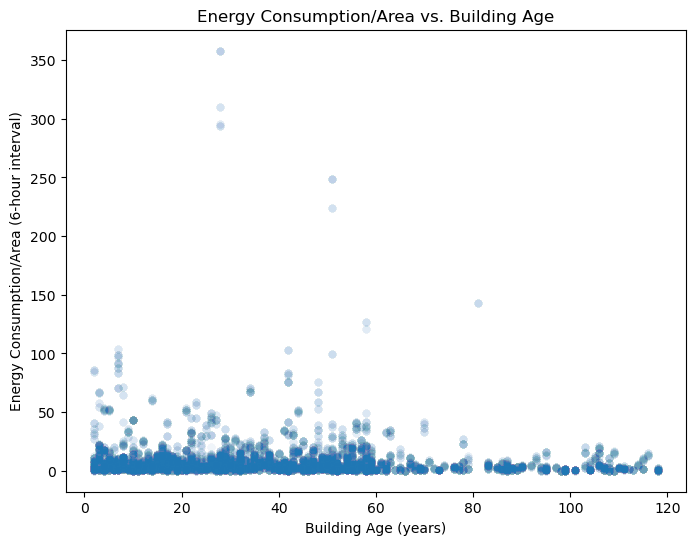

In [24]:
# Convert to pandas 
plot_df1 = plot_df.filter((F.col("peak_offpeak") == "off-peak")).select("year_built", "total_energy", "square_feet", "floor_count").dropna().toPandas()

# Derive building age
plot_df1["building_age"] = 2025 - plot_df1["year_built"]
plot_df1["total_energy"] = (plot_df1["total_energy"]/plot_df1["square_feet"])/plot_df1["floor_count"]

plt.figure(figsize=(8,6))
sns.scatterplot(x="building_age", y="total_energy", data=plot_df1, alpha=0.01)
plt.title("Energy Consumption/Area vs. Building Age")
plt.xlabel("Building Age (years)")
plt.ylabel("Energy Consumption/Area (6-hour interval)")
plt.show()

<b>Findings for CDA1:</b><br>
I initially tested for it using Bi-variate analysis -- Using just the Age and Total Energy Consuption values. The results disproved our assumption that older buildings may not be as efficient as new ones. But this seemed wrong as it went against my intuition so to fine tune the results, I decided to only include "OFF-PEAK" season data -- this way, I will be considering the general usage metrics. Again, the data seemed to disprove my assumption. To finalise my findings I decided to divide the Evergy Consumption with the Gross Floor Area of the building. The plot you see above is the result of this investigation.


As you can see, there seems to be no correlation between the building age and energy consumption. If anything I was being unfair by not including the area earlier but even then the results showed that there wasnt any relation.
<hr>

##### CDA Plot 2: 

Assumption: A multi-floored or larger building obviously consumes more energy.

In [25]:
# We see that single floor buildings largely dominate the data so we will filter out floor = 1 data.
feature_df.groupBy("floor_count").count().orderBy("count", ascending=False).show()

+-----------+-------+
|floor_count|  count|
+-----------+-------+
|          1|7328698|
|          2| 394275|
|          4| 210543|
|          5| 166382|
|          3| 166265|
|          6| 140050|
|          8| 122605|
|          9|  70204|
|          7|  61441|
|         11|  26329|
|         10|  17526|
|         13|  17377|
|         16|   8763|
|         26|   8614|
|         19|   8614|
+-----------+-------+



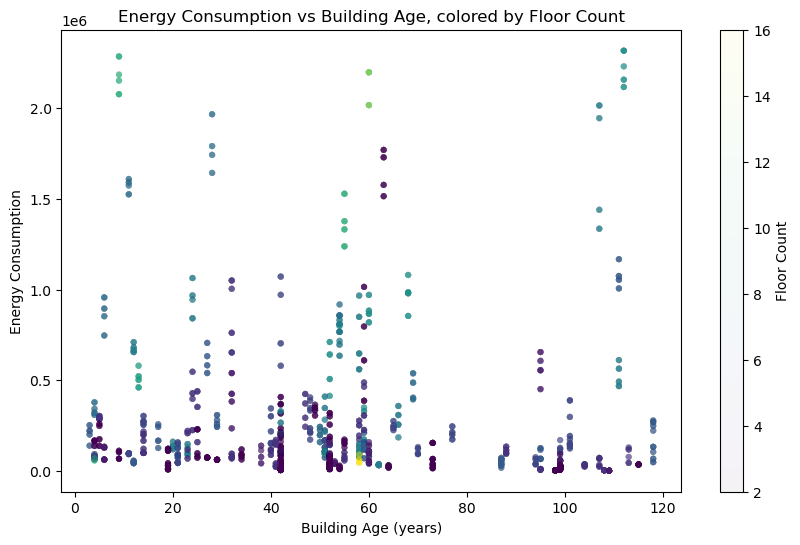

In [26]:
import matplotlib.pyplot as plt

plot_df2 = plot_df.filter((F.col("floor_count") > 1)).select("total_energy", "floor_count", "year_built", "square_feet").dropna().toPandas()

plot_df2["age"] = 2025 - plot_df2["year_built"]

plt.figure(figsize=(10,6))

sc = plt.scatter(
    plot_df2["age"],
    plot_df2["total_energy"],
    c=plot_df2["floor_count"],  # color scale = floor_count
    cmap="viridis",
    s = 20, # point size
    alpha = 0.05,       
    edgecolor='none'
)

plt.xlabel("Building Age (years)")
plt.ylabel("Energy Consumption")
plt.title("Energy Consumption vs Building Age, colored by Floor Count")

cbar = plt.colorbar(sc)
cbar.set_label("Floor Count")

plt.show()

<b>Findings for CDA2:</b><br>
I initially tested for it using Bi-variate analysis -- Using just the Floor Count and Total Energy Consuption values. The results agreed with our assumption that buildings with more floors take up more energy-- a MAJOR Exception of single-floor buildings. Single floor buildings seem to have a  different playbook all together. So inorder to further confirm my suspicions and see a nice spread of the values, I decided to include the AGE variable, which doesnt have any affect on the total_energy as proved in CDA1. I filtered out floor count = 1 values to see the trend. This is the plot you see above.


The hypothesis is true ONLY when we do not include floor_count = 1 data. So will we consider it to be true? Sure. Higher floor count does seem to mean that there will be higher energy consumption. But this doesnt mean that Low Floor Count equals low energy consuption!
<hr>

Below is the bi-variate analysis. 

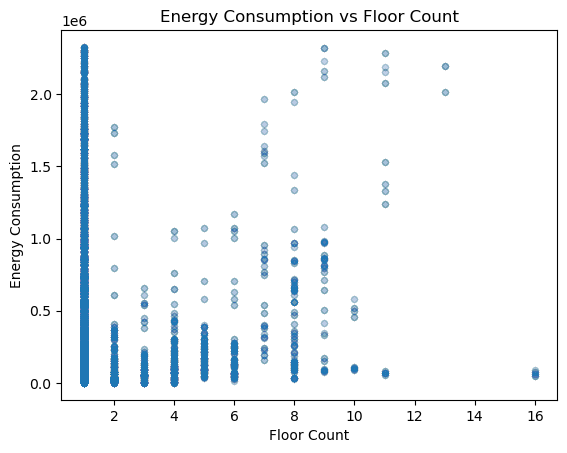

In [27]:
import matplotlib.pyplot as plt

plot_df2 = plot_df.select("total_energy", "floor_count").dropna().toPandas()

plt.figure()

sc = plt.scatter(
    plot_df2["floor_count"],
    plot_df2["total_energy"],
    s = 20, # point size
    alpha = 0.01,       
)

plt.xlabel("Floor Count")
plt.ylabel("Energy Consumption")
plt.title("Energy Consumption vs Floor Count")

plt.show()

## Part 2. Feature extraction and ML training <a class="anchor" name="part-2"></a>
In this section, you must use PySpark DataFrame functions and ML packages for data preparation, model building, and evaluation. Other ML packages, such as scikit-learn, should not be used to process the data; however, it’s fine to use them to display the result or evaluate your model.  
### 2.1 Discuss the feature selection and prepare the feature columns

2.1.1 Based on the data exploration from 1.2 and considering the use case, discuss the importance of those features (For example, which features may be useless and should be removed, which feature has a significant impact on the label column, which should be transformed), which features you are planning to use? Discuss the reasons for selecting them and how you plan to create/transform them.  
○	300 words max for the discussion  
○	Please only use the provided data for model building  
○	You can create/add additional features based on the dataset  
○	Hint - Use the insights from the data exploration/domain knowledge/statistical models to consider whether to create more feature columns, whether to remove some columns  

<hr>

To finalise my features that I want to include in the model, I check the correlation with all numeric columns.

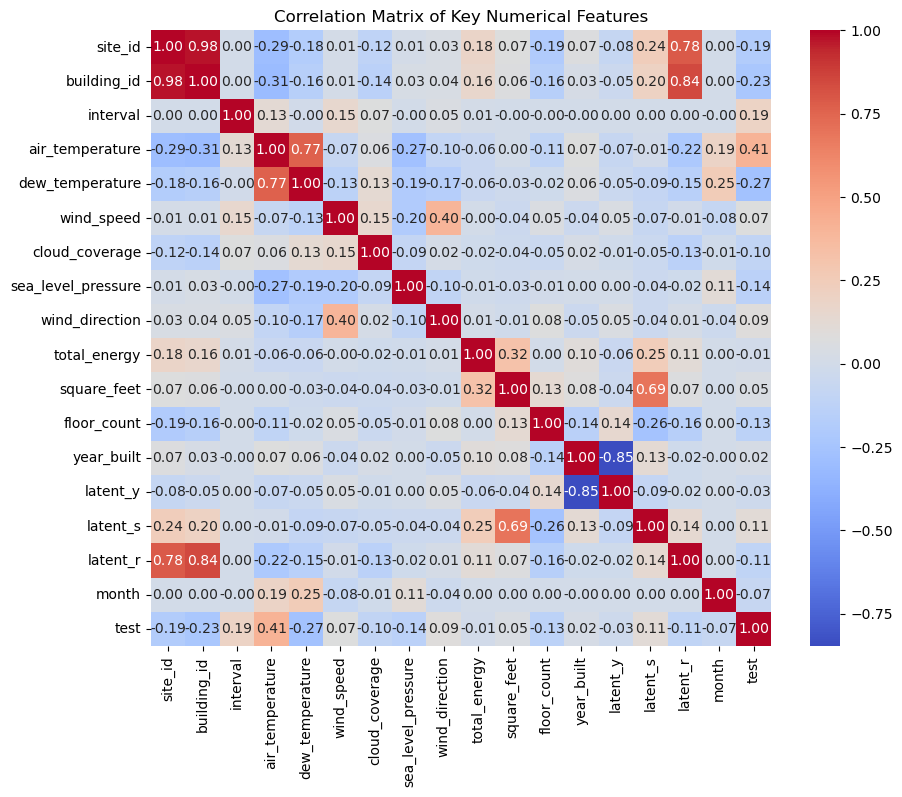

In [28]:
numerical_cols = ["site_id","building_id","interval","air_temperature","dew_temperature","wind_speed",
    "cloud_coverage","sea_level_pressure","wind_direction",
    "total_energy", "square_feet", "floor_count", "year_built",
    "latent_y", "latent_s", "latent_r", "month"]

df_for_corr = feature_df.sample(withReplacement=False, fraction=0.15, seed=35090197)
numerical_df = df_for_corr.select(numerical_cols)
numerical_df = numerical_df.withColumn("test", (F.col("air_temperature")-F.col("dew_temperature")))

corr_pd = numerical_df.toPandas()

plt.figure(figsize=(10, 8))
correlation_matrix = corr_pd.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Numerical Features')
plt.show()

In [29]:
del numerical_df
del corr_pd

From this, I can say that Site_id, building_id, square_feet, and latent_s are the most important features here.<br>
Since site_id and building_id are so closely correlated with eachother, we will only choose site_id.<br>
Latent_s seems to be related to square_feet but that's fine. We will include both anyway.<br>
Interval & air_temp surprisingly have 0 linear relationship with the target.


The features to remove:<br>
While not any features are correlated to Total_energy, we will choose to keep most of them except the following -<br>
1. Latent_y is indirectly strongly correlated to year so we will remove latent_y.
2. air_temp and dew_temp are strongly correlated to eachother so we will keep just one of them -- dew_temperature.
3. Latent_r is strongly correlated to site_id and building_id so we will remove it.
4. timestamp -- not needed.
5. building_id too closely correlated to site_id so we remove.

I tried to engineer some features but none have had good correlation values and so I am not going to engineer new features for this task (other than the one in the next section).<br>
Attempted engineering: 
1. Combinations of temperature data, wind data, cloud cover.
2. Combinations of Site_id, Floor_count, Area, Building Age
3. Combinations of latent variables (Hypothesis: they are just build off of existing variables)
<hr>

2.1.2 Write code to create/transform the columns based on your discussion above.

In [30]:
# 1. Engineering new features.

# For power_consumption data, it is common to include "Weekend" and "Weekday" as a feature (Hussain B, 2021).
# And so, I will also add it.
feature_df = feature_df.withColumn("is_weekend", F.dayofweek("timestamp").isin([7, 1]).cast("int")) #0 or 1 values. 

# Another feature to include is the "test" feature from the above heat-map,
# the temperature difference between air and dew point -- which acts as a proxy for humidity. (Suggested by ChatGPT)
feature_df = feature_df.withColumn("air_dew_diff", (F.col("air_temperature") - F.col("dew_temperature")))
# Now we can remove both, air and dew temps

In [31]:
# 2. Removing features we do not want.
feature_df = feature_df.drop("latent_y", "air_temperature", "dew_temperature", "latent_r", "timestamp", "month", "building_id")

In [32]:
feature_df.limit(5).toPandas().head()

,site_id,interval,cloud_coverage,sea_level_pressure,wind_direction,wind_speed,peak_offpeak,total_energy,primary_use,square_feet,floor_count,year_built,latent_s,is_weekend,air_dew_diff
0,0,0,6,1018.10,270,2.60,peak,1618507.4292,Education,93897,1,2006,4.97265150,1,5.50
1,0,0,6,1018.10,270,2.60,peak,4183477.7963,Education,113866,1,2013,5.05639400,1,5.50
2,0,0,6,1018.10,270,2.60,peak,5309231.7320,Residential,200933,1,2013,5.30305150,1,5.50
3,0,0,6,1018.10,270,2.60,peak,3571826.2561,Other,4698,1,1988,3.67191300,1,5.50
4,0,0,6,1018.10,270,2.60,peak,1388695.6633,Office,16726,1,2018,4.22339200,1,5.50


### 2.2 Preparing Spark ML Transformers/Estimators for features, labels, and models  <a class="anchor" name="2.2"></a>

**2.2.1 Write code to create Transformers/Estimators for transforming/assembling the columns you selected above in 2.1 and create ML model Estimators for Random Forest (RF) and Gradient-boosted tree (GBT) model.
Please DO NOT fit/transform the data yet.**

In [33]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.linalg import Vectors
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor

categoryInputCols = ['peak_offpeak', "primary_use" ]
numericInputCols = ["site_id", "interval", "cloud_coverage","sea_level_pressure", "wind_direction", "wind_speed",
                    "square_feet", "floor_count", "year_built", "latent_s", "is_weekend", "air_dew_diff"
                   ]
categoryOutputCols = [f'{x}_index' for x in categoryInputCols]
outputCols_OHE = [f'{x}_vec' for x in categoryInputCols]

# 1. Preparation
# Handling Categorical Variables First
indexer = StringIndexer(inputCols=categoryInputCols, outputCols=categoryOutputCols) # Indexer set-up/init
encoder = OneHotEncoder(inputCols=categoryOutputCols, outputCols=outputCols_OHE) # Encoder set-up
# VectorAssembler
assemblerInputs = outputCols_OHE + numericInputCols
assembler = VectorAssembler(inputCols = assemblerInputs, outputCol="features") # VectorAssembler set-up

# 2. Modelling
# Random Forrest regressor
rf = RandomForestRegressor(labelCol="total_energy", featuresCol="features", numTrees=10, seed=2025)
# Gradient boosted tree regressor
gbt = GBTRegressor(maxIter=5, maxDepth=2, labelCol="total_energy", seed=2025)

**2.2.2. Write code to include the above Transformers/Estimators into two pipelines.
Please DO NOT fit/transform the data yet.**

In [34]:
from pyspark.ml import Pipeline

# Pipeline_1: Random Forest Pipeline
rf_pipeline = Pipeline(stages=[ indexer, encoder, assembler, rf ])

# Pipeline_2: GBT Pipeline
gbt_pipeline = Pipeline(stages=[ indexer, encoder, assembler, gbt ])

### 2.3 Preparing the training data and testing data  
Write code to split the data for training and testing, using 2025 as the random seed. You can decide the train/test split ratio based on the resources available on your laptop.  
Note: Due to the large dataset size, you can use random sampling (say 20% of the dataset). 

In [35]:
# I am sampling 40% of the dataset to keep computation time manageable
feature_df_sample = feature_df.sample(withReplacement=False, fraction=0.4, seed=2025)

# Train-test splitting -- 80/20 as per spec.
train, test = feature_df_sample.randomSplit([0.8, 0.2], seed = 2025)

### 2.4 Training and evaluating models  
2.4.1 Write code to use the corresponding ML Pipelines to train the models on the training data from 2.3. And then use the trained models to predict the testing data from 2.3

In [36]:
# Random Forrest Pipeline train
rf_model = rf_pipeline.fit(train)
rf_predictions = rf_model.transform(test)

In [37]:
# GBT Pipeline train
gbt_model = gbt_pipeline.fit(train)
gbt_predictions = gbt_model.transform(test)

2.4.2 For both models (RF and GBT): with the test data, decide on which metrics to use for model evaluation and discuss which one is the better model (no word limit; please keep it concise). You may also use a plot for visualisation (not mandatory).

In [38]:
# defining the custom RMSLE Evaluator

from pyspark.ml.evaluation import Evaluator

class RMSLEvaluator(Evaluator):
    def __init__(self, predictionCol="prediction", labelCol="total_energy"):
#         super(RMSLEEvaluator, self).__init__()
        self.predictionCol = predictionCol
        self.labelCol = labelCol

    def _evaluate(self, dataset):
        rmsle_df = dataset.withColumn( "log_diff_sq",
            F.pow(F.log(F.col(self.predictionCol) + 1) - F.log(F.col(self.labelCol) + 1), 2)
        ) # this conputes the individual log error difference.
        mean_log_diff_sq = rmsle_df.select(F.mean("log_diff_sq")).first()[0] # this does the summation cum division (AKA Mean)
        rmsle = mean_log_diff_sq ** 0.5 # single value so we can use python operator for sqrt.
        return rmsle

    def isLargerBetter(self):
        return False # The lower the difference value i.e the rmsle value, the better. And so, larger is NOT better.

In [39]:
rmsle_evaluator = RMSLEvaluator()
rf_rmsle_value = rmsle_evaluator.evaluate(rf_predictions)
gbt_rmsle_value = rmsle_evaluator.evaluate(gbt_predictions)

print(f"RF  RMSLE Value: {rf_rmsle_value}")
print(f"GBT RMSLE Value: {gbt_rmsle_value}")

RF  RMSLE Value: 1.8084187012396362
GBT RMSLE Value: 2.103591405267294


2.4.3 3.	Save the better model (you’ll need it for A2B).
(Note: You may need to go through a few training loops or use more data to create a better-performing model.)

In [40]:
# I tried increasing the dataset sample size but that doesnt seem to help the RMSLE scores.

### Part 3. Hyperparameter Tuning and Model Optimisation <a class="anchor" name="part-3"></a>  
Apply the techniques you have learnt from the labs, for example, CrossValidator, TrainValidationSplit, ParamGridBuilder, etc., to perform further hyperparameter tuning and model optimisation.  
The assessment is based on the quality of your work/process, not the quality of your model. Please include your thoughts/ideas/discussions.

<hr>
<div style="background-color: #FFF6CF; padding: 10px;">
<b>My Discussion: (!! Dear tutor, this section takes about 60mins to run fully. You can refer to the wall times !!)</b>

Below, you will find my code for my attempt at hyperparameter tuning and model optimisation.<br>
I first went through the steps using in Week8 Lab to set-up the ParamGridBuilder and CrossValidator. I went through the documentation to see what hyper-parameters I could tune (and understand the purpose of).<br>
For the RandomForrest Regressor, I cycled through values of: (Please note that value ranges were a limitation of my system.)
1. maxDepth - (value ranges from 0-30) I used values upto 10. Anymore and it crashed.
2. maxBins -  (any value > 0) --  I used values upto 30
3. numTrees - (any value >= 1) -- I used values upto 30

For the GBT Regressor:
1. maxDepth - (values range from 0-30) -- I experimented using values upto 15.
2. maxIter -  (any value > 0) -- I used values up to 6
3. maxBins -  (used default value -- 32)

For the cross validator, I was limited to <b>2 Folds</b> due to OOM issues. But this still gave good results.<br>

Evaluator:<br>The evaluator I used was the custom RMSLE that we created in the previous section of this assignment.<br>
This evaluator handles large values and small values appropriately; what I mean is, the difference between numbers is appropriately penalised thanks to the Log conversions applied (relative error). This evaluator takes the relative "distance" (or error) between the two values rather than the absolute difference so it is great when we are dealing with continuous target variables such as our case where Total_Energy is a continuous variable with a wide range of values.<br>
I extracted the RMSLE value after every cross validator to assess the difference between the many BestModels.

Other adjustments:
1. I experimented using different sample sizes. I tried using values between 0.05 to 0.40. I tried to keep the larger fraction.
2. The target variable seems to have some outliers that might skew the predictions. RMSLE heavily penalises large error and having exception cases will unnecessarily penalise the model. And so, I used the IQR method for removing outliers as I had previously done.
3. I ran multiple itterations of the CrossValidator and tried many values for ParamGrid to try improve results.
</div>

In [41]:
# I will go through all the steps covered in lab 8 part B to try my hand at Hyper Parameter Tuning.

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, CrossValidatorModel

rf_paramGrid = (ParamGridBuilder()
            .addGrid(rf.maxDepth, [2, 5, 10])
            .addGrid(rf.maxBins, [20, 30])
            .addGrid(rf.numTrees, [10, 20])
            .build())

In [42]:
# using a slightly smaller sample size for faster processing:
feature_df_sample = feature_df.sample(withReplacement=False, fraction=0.4, seed=2025)

# To further help with the accuracy, I will eliminate the outliers in the dataset by using the method I used in the
# data analysis section:
column = "total_energy"
quantiles = feature_df_sample.approxQuantile(column, [0.25, 0.75], 0.01)
q1, q3 = quantiles[0], quantiles[1]
iqr = q3 - q1
factor = 1.5

# Define the upper and lower bounds for outliers
lower_bound = q1 - factor * iqr
upper_bound = q3 + factor * iqr

# Filter outliers and update the DataFrame
feature_df_sample = feature_df_sample.filter((F.col(column) >= lower_bound) & (F.col(column) <= upper_bound))

# Train-test splitting -- 80/20 as per spec.
train, test = feature_df_sample.randomSplit([0.8, 0.2], seed = 2025)

In [43]:
import gc
gc.collect()
del plot_df
del plot_df1
del plot_df2
del feature_df
del feature_df_sample

In [44]:
rf_cv = CrossValidator(estimator = rf_pipeline,
                      estimatorParamMaps = rf_paramGrid,
                      evaluator = rmsle_evaluator,
                      numFolds = 2)

In [45]:
%%time # Wall time - 11mins
rf_cvModel = rf_cv.fit(train)
gc.collect()

CPU times: user 1.87 s, sys: 1.08 s, total: 2.95 s
Wall time: 10min 44s


2250

In [46]:
#Getting the best model and the optimum parameters selected from the Cross Validation 
bestModelRF= rf_cvModel.bestModel
print(bestModelRF.stages)
print('Best Param for RF: ', bestModelRF.stages[-1]._java_obj.paramMap())

[StringIndexerModel: uid=StringIndexer_07894635dc8c, handleInvalid=error, numInputCols=2, numOutputCols=2, OneHotEncoderModel: uid=OneHotEncoder_c1bb8fe83ddf, dropLast=true, handleInvalid=error, numInputCols=2, numOutputCols=2, VectorAssembler_9b5628bdd9b6, RandomForestRegressionModel: uid=RandomForestRegressor_656eee085a77, numTrees=20, numFeatures=28]
Best Param for RF:  {
	RandomForestRegressor_656eee085a77-featuresCol: features,
	RandomForestRegressor_656eee085a77-labelCol: total_energy,
	RandomForestRegressor_656eee085a77-maxBins: 20,
	RandomForestRegressor_656eee085a77-maxDepth: 10,
	RandomForestRegressor_656eee085a77-numTrees: 20,
	RandomForestRegressor_656eee085a77-seed: 2025
}


In [47]:
%%time #Wall time: 7mins
gbt_paramGrid = (ParamGridBuilder()
                 .addGrid(gbt.maxIter, [2, 5, 7])
                 .addGrid(gbt.maxDepth, [2, 3, 4])
                 .build())

gbt_cv = CrossValidator(estimator = gbt_pipeline,
                      estimatorParamMaps = gbt_paramGrid,
                      evaluator = rmsle_evaluator,
                      numFolds = 2)
gbt_cvModel = gbt_cv.fit(train)
gc.collect()

CPU times: user 1.48 s, sys: 811 ms, total: 2.29 s
Wall time: 6min 46s


1235

In [48]:
bestModelGBT= gbt_cvModel.bestModel
print(bestModelGBT.stages)
print('Best Param for GBT: ', bestModelGBT.stages[-1]._java_obj.paramMap())

[StringIndexerModel: uid=StringIndexer_07894635dc8c, handleInvalid=error, numInputCols=2, numOutputCols=2, OneHotEncoderModel: uid=OneHotEncoder_c1bb8fe83ddf, dropLast=true, handleInvalid=error, numInputCols=2, numOutputCols=2, VectorAssembler_9b5628bdd9b6, GBTRegressionModel: uid=GBTRegressor_45619cd2d60c, numTrees=7, numFeatures=28]
Best Param for GBT:  {
	GBTRegressor_45619cd2d60c-labelCol: total_energy,
	GBTRegressor_45619cd2d60c-maxDepth: 4,
	GBTRegressor_45619cd2d60c-maxIter: 7,
	GBTRegressor_45619cd2d60c-seed: 2025
}


In [49]:
best_gbt_rmsle = min(gbt_cvModel.avgMetrics)
print("Best GBT RMSLE:", best_gbt_rmsle)

best_rf_rmsle = min(rf_cvModel.avgMetrics)
print("Best RF RMSLE:", best_rf_rmsle)

Best GBT RMSLE: 1.3479743999237432
Best RF RMSLE: 1.005179336028766


In [51]:
# Wayy better than the original models!!

bestModelRF.save('A2_prediction_model_RF_2')

I am running another itteration of Cross Validation Split with different values.

In [52]:
%%time #Wall Time - 12 mins
gbt_paramGrid = (ParamGridBuilder()
                 .addGrid(gbt.maxIter, [7, 10])
                 .addGrid(gbt.maxDepth, [4, 5, 6])
                 .addGrid(gbt.maxBins, [10, 20])
                 .build())
# For some reason not re-defining the CV gave me the older results.
gbt_cv = CrossValidator(estimator = gbt_pipeline,
                      estimatorParamMaps = gbt_paramGrid,
                      evaluator = rmsle_evaluator,
                      numFolds = 2)

del gbt_cvModel
gbt_cvModel = gbt_cv.fit(train)

bestModelGBT= gbt_cvModel.bestModel
print(bestModelGBT.stages)
print('Best Param for GBT: ', bestModelGBT.stages[-1]._java_obj.paramMap())

best_gbt_rmsle = min(gbt_cvModel.avgMetrics)
print("Best GBT RMSLE:", best_gbt_rmsle)

gc.collect()

[StringIndexerModel: uid=StringIndexer_07894635dc8c, handleInvalid=error, numInputCols=2, numOutputCols=2, OneHotEncoderModel: uid=OneHotEncoder_c1bb8fe83ddf, dropLast=true, handleInvalid=error, numInputCols=2, numOutputCols=2, VectorAssembler_9b5628bdd9b6, GBTRegressionModel: uid=GBTRegressor_45619cd2d60c, numTrees=10, numFeatures=28]
Best Param for GBT:  {
	GBTRegressor_45619cd2d60c-labelCol: total_energy,
	GBTRegressor_45619cd2d60c-maxBins: 10,
	GBTRegressor_45619cd2d60c-maxDepth: 6,
	GBTRegressor_45619cd2d60c-maxIter: 10,
	GBTRegressor_45619cd2d60c-seed: 2025
}
Best GBT RMSLE: 1.1999307059109316
CPU times: user 2.14 s, sys: 1.14 s, total: 3.28 s
Wall time: 11min 54s


2299

Random Forrest Regressor is consistently performing better than the GBT.

<b>The following screenshot shows my System Crashing. I am demostrating the limitations of my system.</b><br>


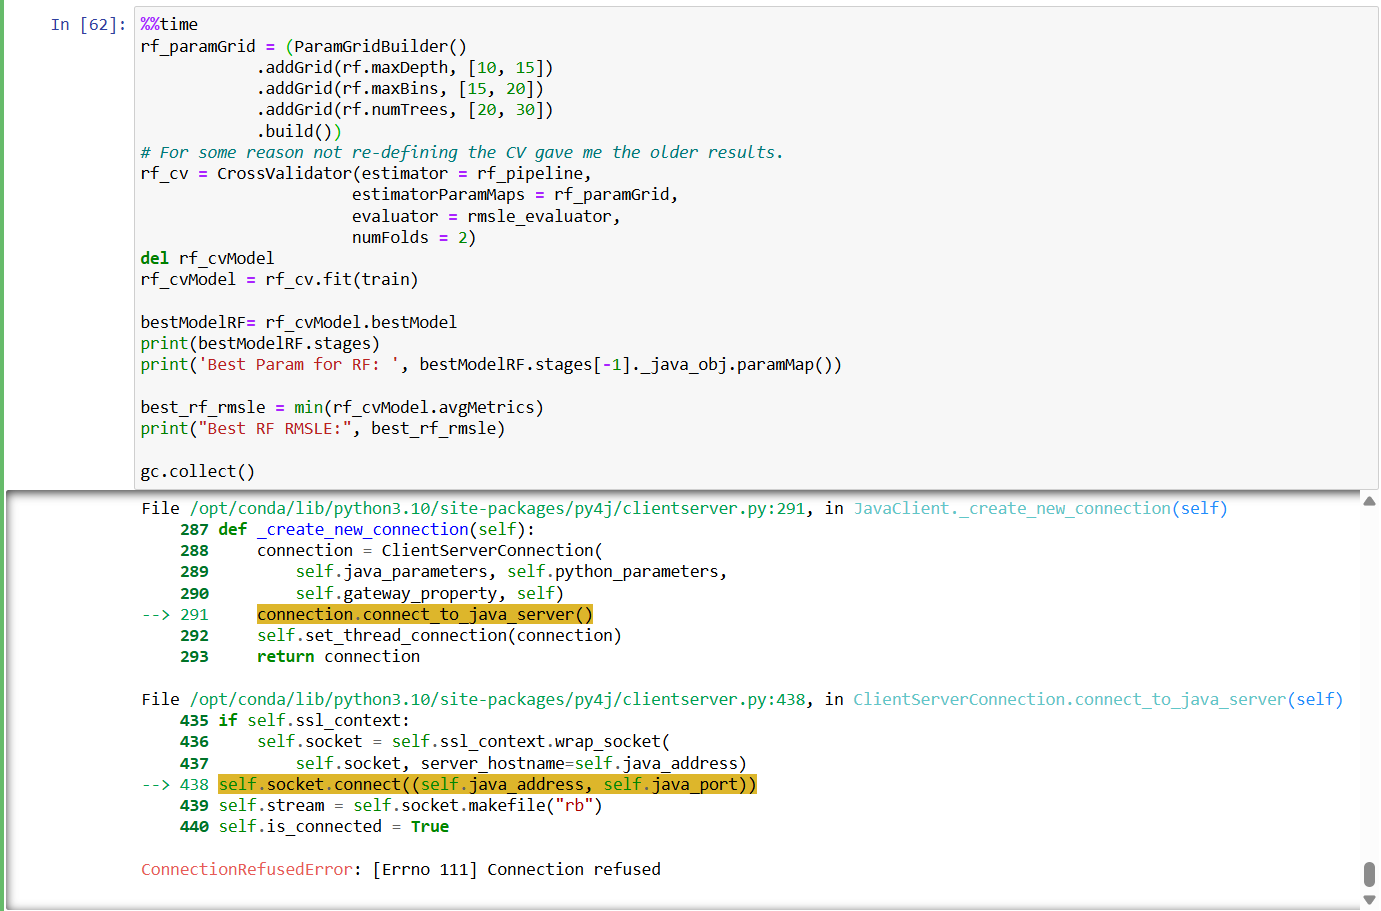

In [57]:
%%time # Wall time - 20mins
rf_paramGrid = (ParamGridBuilder()
                .addGrid(rf.maxDepth, [10, 11])
                .addGrid(rf.maxBins, [15, 20])
                .addGrid(rf.numTrees, [20, 30])
                .build())
# For some reason not re-defininf the CV gave me the older results.
rf_cv = CrossValidator(estimator = rf_pipeline,
                      estimatorParamMaps = rf_paramGrid,
                      evaluator = rmsle_evaluator,
                      numFolds = 2)

rf_cvModel = rf_cv.fit(train)
bestModelRF = rf_cvModel.bestModel
print(bestModelRF.stages)
print('Best Param for RF: ', bestModelRF.stages[-1]._java_obj.paramMap())

best_rf_rmsle = min(rf_cvModel.avgMetrics)
print("Best RF RMSLE:", best_rf_rmsle)

gc.collect()

[StringIndexerModel: uid=StringIndexer_07894635dc8c, handleInvalid=error, numInputCols=2, numOutputCols=2, OneHotEncoderModel: uid=OneHotEncoder_c1bb8fe83ddf, dropLast=true, handleInvalid=error, numInputCols=2, numOutputCols=2, VectorAssembler_9b5628bdd9b6, RandomForestRegressionModel: uid=RandomForestRegressor_656eee085a77, numTrees=30, numFeatures=28]
Best Param for RF:  {
	RandomForestRegressor_656eee085a77-featuresCol: features,
	RandomForestRegressor_656eee085a77-labelCol: total_energy,
	RandomForestRegressor_656eee085a77-maxBins: 20,
	RandomForestRegressor_656eee085a77-maxDepth: 11,
	RandomForestRegressor_656eee085a77-numTrees: 30,
	RandomForestRegressor_656eee085a77-seed: 2025
}
Best RF RMSLE: 0.9221691057287515
CPU times: user 1.4 s, sys: 658 ms, total: 2.06 s
Wall time: 19min 42s


2786

Best model yet. Saving it:

In [64]:
bestModelRF.save('A2_prediction_model_RF_09221Score')

<b>Evaluating Sensor Data in meters_df</b>

In [61]:
meters_df = spark.read.csv("meters.csv", header=True, schema=meters_schema)
meters_df_temp = meters_df.drop("ts")
meters_df_temp.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in meters_df_temp.columns]).show()
del meters_df_temp
gc.collect()

meters_df.count()

+-----------+----------+-----+------+
|building_id|meter_type|value|row_id|
+-----------+----------+-----+------+
|          0|         0| 3067|     0|
+-----------+----------+-----+------+



13825018

In [69]:
print(f"That is only {(3067 / 13825018) * 100}% of the target label that is missing.")

That is only 0.022184419579055883% of the target label that is missing.


So, I think the performance improvement will probably only be marginal.<br>
Then again, we are taking a sample of the dataset for our model training and testing so imputation, in my opinion, will not add much.<br>

And so, I will not attempt Imputation.
<hr>

### Part 4. Data Ethics, Privacy, and Security <a class="anchor" name="part-4"></a> 

<b>Definitions:</b><br>

1.	BigData Ethics:
“The field of big data ethics is defined as outlining, defending and recommending concepts of right and wrong practice when it comes to the use of data, with particular emphasis on personal data” (McCabe, A., 2023). 

2.	BigData Privacy:
“Big data privacy concerns refer to the threats and risks associated with collecting, storing, analyzing, and using vast amounts of personal information in the era of data-driven decision-making” (Chancey, T., 2024). 

3.	BigData Security:
“Big data security is a set of data security measures and practices to safeguard large volumes of data, known as "big data," from malware attacks, unauthorized access, and other security threats. The process involves protecting the confidentiality, integrity, and accessibility of data” (Dutta, S., 2025).


<b>Significance of the issues:</b><br>

1.	Ethics:
In the contemporary world, there is constant data collection – active and passive—and this begs the questions: how intrusive is too intrusive, how much collection is too much collection, etc. These are addressed by the discussions around Ethics in Big Data.<br>
Challenges:<br>
a.	Informed Consent – Ethical collection of user data with their explicit consent and knowledge of what is being collected and what it will be used for.<br> 
b.	Privacy – Keeping data anonymised and ensure re-identification is not possible.<br>
c.	Ownership – Give the user the control of their data. Complete transparency and ability to retract data collected.<br>
d.	Algorithm bias and objectivity – Big Data is often used for machine learning and human bias can seep into this. We must ensure data being used let alone collected is objective and inclusive.<br>


2.	Privacy:
It’s one of the greatest challenges in big data because of the volume and interconnectedness of datasets. Even anonymised data can often be re-identified, raising significant risks. Heavy repercussions in fields such as Medicine, Law and Finance, etc.<br>
Challenges:<br>
a.	Re-use of data for new purposes: Unconsented use of sensitive data.<br>
b.	Lack of transparency: People have no control over the data collected from/about them.<br>
c.	Security implications & risk of re-identification.<br>
d.	Echo chambers – People view targeted content that leaves them in a bubble of their of beliefs – potentially unhealthy.<br>


3.	Security:
It’s the process of monitoring and protecting a company’s important business data with the goal of ensuring safe and compliant ongoing operation. This leads to protection of company’s important IP as well as sensitive and identifiable user data!<br>
Challenges:<br>
a.	Constant updates & Training: Security protocols are ever changing and malicious actors are ever evolving. Keeping things up-to-date is tedious, expensive but necessary.<br>
b.	New tech & vulnerability: We are actively switching and adopting new tech and there is new tech emerging every day. The success of ChatGPT was over-night but new tech often comes with new security vulnerabilities.<br>
c.	Auth.: Authentication and authorization to access the sensitive data is a major challenge. Global workforces sharing data is a major challenge.<br>
d.	Physical Security: Keeping datacentres safe from physical bugs, wire-taps, etc is often neglected.<br>


<b>Summary:</b><br>
BigData ethics, privacy, and security are interlinked foundations for responsible big data use. Ethical practices influence trust and legitimacy, while privacy protections safeguard individual rights against misuse. Security mechanisms ensure that these values are practically enforced against technical threats. Together, these dimensions highlight that innovation in big data must be balanced by accountability, regulatory compliance, and proactive governance.


## References: <a class="anchor" name="references"></a> 

Amit Kumar. ( 2025 ). <i>The Role of ‘maxPartitionBytes’ Configuration Parameter in Spark Data Partitioning</i>. Medium.<br>
https://medium.com/the-data-blackbox-unraveling-the-mysteries-of-data/the-role-of-spark-sql-files-maxpartitionbytes-parameter-in-spark-data-partitioning-4b2e22361990

ApacheSpark. ( Accessed 2025 ). <i>Data Types</i>. Apache Spark API Reference.<br>
https://spark.apache.org/docs/latest/sql-ref-datatypes.html 

ApacheSpark. ( Accessed 2025 ). <i>pyspark.ml.regression.GBTRegressor</i>. Apache Spark API Reference.
https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.GBTRegressor.html

ApacheSpark. ( Accessed 2025 ). <i>pyspark.ml.regression.RandomForestRegressor</i>. Apache Spark API Reference.
https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.RandomForestRegressor.html

ApacheSpark. ( Accessed 2025 ). <i>spark.files.maxPartitionBytes</i>. Spark Configuration.<br>
https://spark.apache.org/docs/latest/configuration.html#memory-management

Bennett, S. ( Accessed 2025 ). <i>Big data, privacy and information governance: Incorporating an ethical-based assessment</i>. Governance Institute Australia.<br>
https://www.governanceinstitute.com.au/news_media/big-data-privacy-and-information-governance-incorporating-an-ethical-based-assessment/

Chancey, T. ( 2024 ) <i>Big Data Privacy Issues: Protect Your Data with Advanced Analytics and Security</i>. Scarllet Group.<br>
https://www.scarlettgroup.com/big-data-privacy-concerns

Crockett, E. ( 2023 ). <i>What is Big Data Security? Challenges & Solutions</i>. Datamation.<br>
https://www.datamation.com/big-data/big-data-security/#challenges

Dutta, S. ( 2025 ). <i>Big Data Security: Advantages, Challenges, and Best Practices</i>. Turing.<br>
https://www.turing.com/resources/big-data-security

FIT5202 Teaching Team. ( 2025 ). <i>Weekly Learning Material</i>. Monash University.<br>
https://learning.monash.edu/course/view.php?id=31424&section=0

Hussain, B. ( 2021 ). <i>How Feature Engineering Trumps Algorithms</i>. ClearPeaks.<br>
https://www.clearpeaks.com/how-feature-engineering-trumps-algorithms/

MachinelearingPlus. ( Accessed 2025 ). <i>PySpark Outlier Detection and Treatment – A Comprehensive Guide How to handle Outlier in PySpark. 4. How to Detect and Treat Outliers using IQR method</i>. Machinelearning Plus<br>
https://www.machinelearningplus.com/pyspark/pyspark-outlier-detection-and-treatment/

McCabe, A. ( 2023 ). <i>The Ethics of Big Data</i>. Hurre.<br>
https://blog.hurree.co/the-ethics-of-big-data

Neelamali, N. ( 2025 ). <i>PySpark Read CSV file into DataFrame</i>. Spark By Examples.<br>
https://sparkbyexamples.com/pyspark/pyspark-read-csv-file-into-dataframe/

Yan, C. ( 2023 ). <i>Custom and Implementation Evaluation Metrics in PySpark MLlib</i>. Medium.<br> https://chrisyandata.medium.com/custom-and-implementation-evaluation-metrics-in-pyspark-mllib-8a23121c298d

### AI Statement  <a class="anchor" name="ai-statement"></a> 

I used ChatGPT5o and ChatGPT5o-mini (https://chatgpt.com/) to understand various concepts in this assignment such as hyperparameters of RandomForrests and GBTs, other conceptual Machine Learning doubts, some PySpark syntax (DataFrameAPI) and MatplotLib, and also to help me understand the math behind the RMSLE formula/error calculations. I also used it for suggestions for feature engineering -- humidity proxy sugegestion.